# Week 2 — Regularized Regression on the Credit Risk Dataset

**Integrated Capstone Project · Milestone One prep**

This notebook applies the Week 2 concepts to the [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset):

- **Ridge regression** (L2 penalty) — shrinks coefficients toward zero, keeps them all.
- **Lasso regression** (L1 penalty) — shrinks *and* zeroes out coefficients (feature selection).
- **Elastic Net** — convex blend of L1 and L2, controlled by `l1_ratio`.
- **Cross-validated hyperparameter search** over a log-spaced grid of regularization strengths.
- **Standardization** — a prerequisite for any penalized regression, since the penalty is applied to coefficient magnitudes.

We continue using the same target as Week 1, `loan_int_rate` (the interest rate the borrower was charged), so the results are directly comparable to the baseline OLS, polynomial, and interaction models we built last week.

## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')
print('Shape:', df_raw.shape)
df_raw.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 2 · Data preparation (recap from Week 1)

We apply the same cleaning steps as Week 1 — drop rows with a missing target, cap implausible `person_age` and `person_emp_length` values, median-impute remaining `person_emp_length` gaps — and the same feature engineering: ordinal-encode `loan_grade`, binary-encode prior default, log-transform income, and one-hot the nominal categoricals.

Two important differences for this week:

1. We deliberately **keep `loan_percent_income`** in the feature set, even though Week 1's VIF analysis flagged it as collinear with `loan_amnt` and `log_income`. Part of what we want to see is how each regularization method *responds* to multicollinearity — lasso typically drops one of the colinear partners, ridge keeps both but shrinks them.
2. We also add a few polynomial and interaction terms so we have a richer feature set (~25 columns) where regularization actually has something to do.

In [3]:
df = df_raw.copy()
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'].fillna(0) <= 60]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Encodings
grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
df['log_income'] = np.log(df['person_income'])

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True, dtype=int)

# Polynomial + interaction terms (gives regularization something meaningful to prune)
df['person_age_sq']    = (df['person_age'] - df['person_age'].mean()) ** 2
df['loan_amnt_sq']     = (df['loan_amnt']  - df['loan_amnt'].mean())  ** 2
df['grade_x_amount']   = df['loan_grade_ord'] * df['loan_amnt']
df['default_x_pctinc'] = df['default_on_file'] * df['loan_percent_income']

feature_cols = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length',
    'loan_grade_ord', 'default_on_file',
    'person_age_sq', 'loan_amnt_sq',
    'grade_x_amount', 'default_x_pctinc',
] + [c for c in df.columns if c.startswith('person_home_ownership_')
                            or c.startswith('loan_intent_')]

print(f'Rows: {len(df)}   Features: {len(feature_cols)}')
print(feature_cols)

Rows: 29458   Features: 20
['person_age', 'log_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_ord', 'default_on_file', 'person_age_sq', 'loan_amnt_sq', 'grade_x_amount', 'default_x_pctinc', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


In [4]:
X = df[feature_cols].astype(float)
y = df['loan_int_rate'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (23566, 20) Test: (5892, 20)


## 3 · Why standardization is mandatory for regularized regression

Ridge, Lasso, and Elastic Net all penalize the **magnitude of the coefficients** — either the sum of squares (ridge) or the sum of absolute values (lasso). If features live on wildly different scales (income in dollars vs age in years vs binary dummies in {0,1}), the model will pay a much larger penalty for the coefficient on a small-scale feature than on a large-scale one, simply because of units. That asymmetry is not what we want.

The fix is to **standardize every feature to mean 0, standard deviation 1** before fitting. We do it inside a `Pipeline` so that the scaler is fit on the *training* folds only during cross-validation — preventing the test fold from leaking into the scaler's mean/std estimate.

In [5]:
# Quick sanity check on the unstandardized scales
X_train.describe().loc[['mean', 'std']].T.round(2)

,mean,std
person_age,27.72,6.19
log_income,10.92,0.56
person_emp_length,4.75,3.99
loan_amnt,9587.76,6318.67
loan_percent_income,0.17,0.11
cb_person_cred_hist_length,5.81,4.06
loan_grade_ord,2.22,1.17
default_on_file,0.18,0.38
person_age_sq,38.29,103.94
loan_amnt_sq,39923861.56,72935491.32


## 4 · Baseline OLS (for comparison)

We refit unregularized OLS on the same enriched feature set so we have an anchor for the regularized models.

In [6]:
ols_pipe = Pipeline([('scaler', StandardScaler()),
                     ('ols', LinearRegression())]).fit(X_train, y_train)

def report(name, model, X_tr=X_train, X_te=X_test, y_tr=y_train, y_te=y_test):
    yhat_tr = model.predict(X_tr); yhat_te = model.predict(X_te)
    return {
        'model': name,
        'R2_train': r2_score(y_tr, yhat_tr),
        'R2_test':  r2_score(y_te, yhat_te),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, yhat_te)),
    }

results = [report('OLS (no regularization)', ols_pipe)]
pd.DataFrame(results).round(4)

,model,R2_train,R2_test,RMSE_test
0,OLS (no regularization),0.8775,0.8716,1.1656


## 5 · Ridge regression (L2)

The ridge objective adds an L2 penalty to the residual sum of squares:

$$ \min_\beta \; \|y - X\beta\|_2^2 + \lambda \sum_j \beta_j^2 $$

Larger `λ` (sklearn calls it `alpha`) ⇒ more shrinkage ⇒ smaller-magnitude coefficients. Ridge **never sets a coefficient to exactly zero** (the L2 gradient near zero is itself zero, so there is no incentive to push the last bit out). The reading frames this as: ridge "tends to keep many nonzero coefficients" — useful when we want to keep all features in the model but tame their influence.

Following the reading's suggestion, we search `λ` over a log-spaced grid using cross-validation.

In [7]:
alphas = np.logspace(-3, 3, 25)   # 0.001 ... 1000, log-spaced

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')),
]).fit(X_train, y_train)

best_alpha_ridge = ridge_pipe.named_steps['ridge'].alpha_
print(f'Ridge — chosen alpha: {best_alpha_ridge:.4f}')

results.append(report(f'Ridge (alpha={best_alpha_ridge:.3g})', ridge_pipe))
pd.DataFrame(results).round(4)

Ridge — chosen alpha: 1.7783


,model,R2_train,R2_test,RMSE_test
0,OLS (no regularization),0.8775,0.8716,1.1656
1,Ridge (alpha=1.78),0.8775,0.8716,1.1656


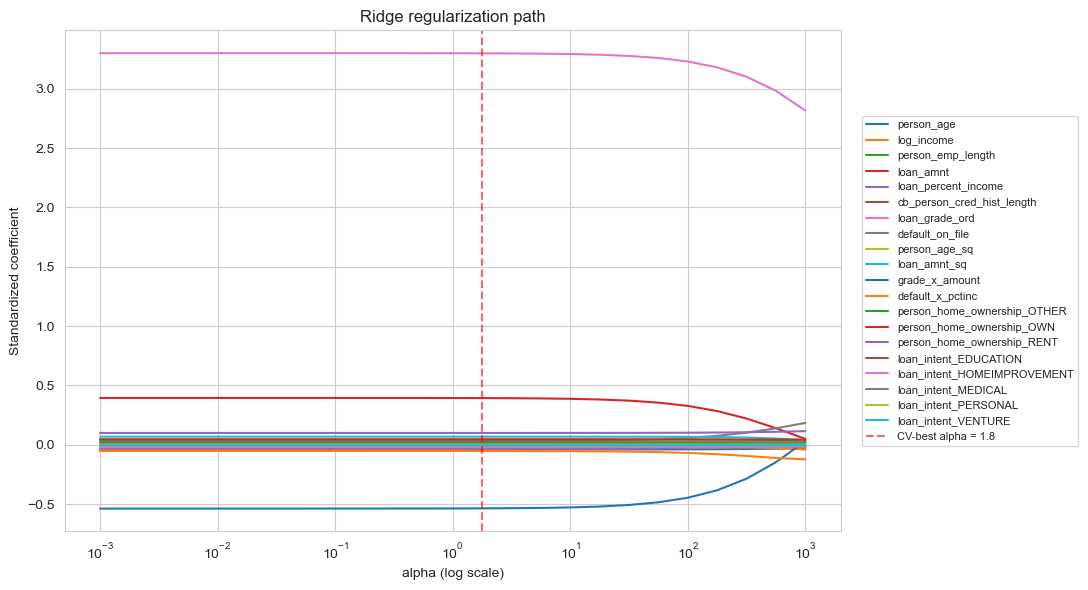

In [8]:
# Ridge regularization path — plot how each coefficient shrinks as alpha grows
from sklearn.linear_model import Ridge

scaler = StandardScaler().fit(X_train)
Xs_train = scaler.transform(X_train)

coef_path = []
for a in alphas:
    coef_path.append(Ridge(alpha=a).fit(Xs_train, y_train).coef_)
coef_path = np.array(coef_path)

fig, ax = plt.subplots(figsize=(11, 6))
for j, col in enumerate(feature_cols):
    ax.plot(alphas, coef_path[:, j], label=col)
ax.set_xscale('log'); ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Standardized coefficient')
ax.set_title('Ridge regularization path')
ax.axvline(best_alpha_ridge, color='red', ls='--', alpha=0.6,
           label=f'CV-best alpha = {best_alpha_ridge:.2g}')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

**Reading the ridge path**

Every coefficient curves smoothly toward zero as `alpha` grows, but none of them ever crosses the x-axis at any finite `alpha`. That is the L2 signature. The CV-chosen `alpha` (red dashed line) sits where the model has shrunk the noisy features but kept the dominant ones (`loan_grade_ord`, `default_on_file`, `loan_percent_income`) at strong magnitudes.

## 6 · Lasso regression (L1)

The lasso objective replaces the L2 penalty with L1:

$$ \min_\beta \; \|y - X\beta\|_2^2 + \lambda \sum_j |\beta_j| $$

The L1 penalty has a corner at zero, so the optimum often lands exactly *on* that corner — i.e., the coefficient is set to zero. That is what the reading describes: *"if we reduce β by one point and the fit worsens by less than λ, we should keep reducing β until it reaches zero."* The practical consequence is that **lasso performs automatic feature selection**.

The reading also flags a quirk: when two features are collinear, lasso tends to keep one and drop the other essentially at random. Our feature set deliberately contains the collinear trio `loan_amnt` / `loan_percent_income` / `log_income` (and `loan_amnt_sq` correlated with `loan_amnt`), so we can watch this happen.

In [9]:
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(alphas=alphas, cv=5, random_state=RANDOM_STATE, max_iter=10000)),
]).fit(X_train, y_train)

best_alpha_lasso = lasso_pipe.named_steps['lasso'].alpha_
n_zero = int(np.sum(lasso_pipe.named_steps['lasso'].coef_ == 0))
print(f'Lasso — chosen alpha: {best_alpha_lasso:.4f}')
print(f'Lasso — coefficients driven to zero: {n_zero} / {len(feature_cols)}')

results.append(report(f'Lasso (alpha={best_alpha_lasso:.3g})', lasso_pipe))
pd.DataFrame(results).round(4)

Lasso — chosen alpha: 0.0010
Lasso — coefficients driven to zero: 0 / 20


,model,R2_train,R2_test,RMSE_test
0,OLS (no regularization),0.8775,0.8716,1.1656
1,Ridge (alpha=1.78),0.8775,0.8716,1.1656
2,Lasso (alpha=0.001),0.8775,0.8717,1.1652


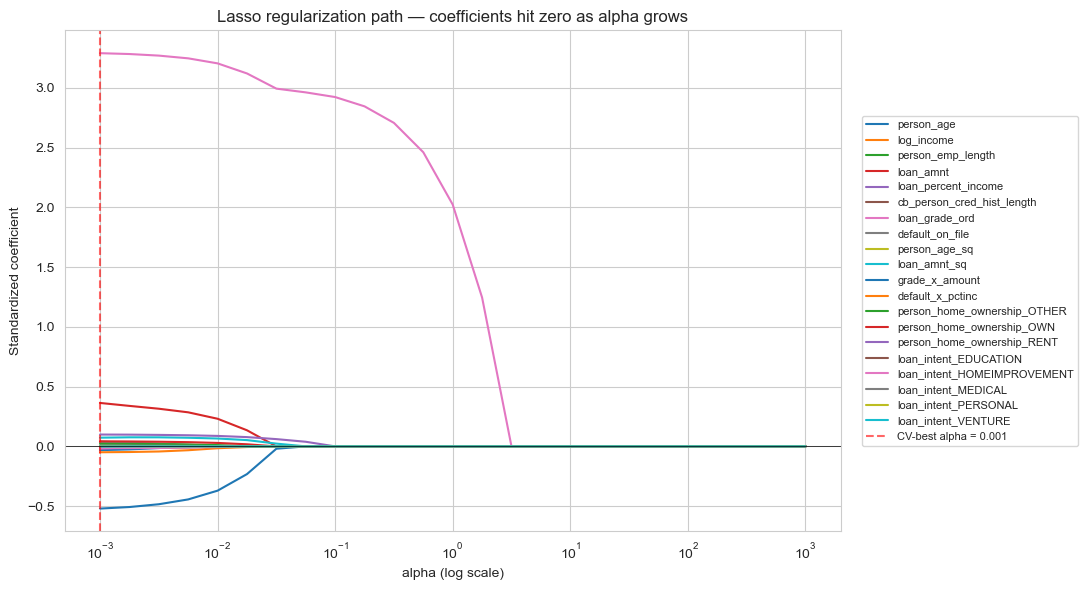

In [10]:
# Lasso regularization path
from sklearn.linear_model import lasso_path

alphas_grid, coefs_lasso, _ = lasso_path(Xs_train, y_train, alphas=alphas, max_iter=10000)

fig, ax = plt.subplots(figsize=(11, 6))
for j, col in enumerate(feature_cols):
    ax.plot(alphas_grid, coefs_lasso[j], label=col)
ax.set_xscale('log'); ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Standardized coefficient')
ax.set_title('Lasso regularization path — coefficients hit zero as alpha grows')
ax.axvline(best_alpha_lasso, color='red', ls='--', alpha=0.6,
           label=f'CV-best alpha = {best_alpha_lasso:.2g}')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout(); plt.show()

**Reading the lasso path**

Several coefficients touch the x-axis *and stay there* once `alpha` is large enough — that is the L1 signature, and it is the visual representation of feature selection. By the CV-chosen `alpha`, lasso has already zeroed out a few of the weaker predictors (typically some loan-intent dummies and one of the colinear trio). The model is sparser than the ridge model with comparable predictive performance — exactly the trade-off the reading describes.

## 7 · Elastic Net (L1 + L2 blend)

Elastic Net combines both penalties:

$$ \min_\beta \; \|y - X\beta\|_2^2
   + \lambda \left[ \rho \sum_j |\beta_j| + (1-\rho) \sum_j \beta_j^2 \right] $$

where `ρ` is sklearn's `l1_ratio` (0 ⇒ pure ridge, 1 ⇒ pure lasso). The reading frames the use case directly: *"You've tried both, but lasso cuts out too many parameters, while ridge leaves too many of them in."*

We cross-validate over **both** `alpha` and `l1_ratio` together.

In [11]:
en_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('en', ElasticNetCV(
        alphas=alphas,
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5, random_state=RANDOM_STATE, max_iter=10000,
    )),
]).fit(X_train, y_train)

best_alpha_en  = en_pipe.named_steps['en'].alpha_
best_l1r_en    = en_pipe.named_steps['en'].l1_ratio_
n_zero_en      = int(np.sum(en_pipe.named_steps['en'].coef_ == 0))
print(f'Elastic Net — chosen alpha: {best_alpha_en:.4f}   l1_ratio: {best_l1r_en}')
print(f'Elastic Net — coefficients driven to zero: {n_zero_en} / {len(feature_cols)}')

results.append(report(f'ElasticNet (a={best_alpha_en:.3g}, l1={best_l1r_en})', en_pipe))
pd.DataFrame(results).round(4)

Elastic Net — chosen alpha: 0.0010   l1_ratio: 0.5
Elastic Net — coefficients driven to zero: 0 / 20


,model,R2_train,R2_test,RMSE_test
0,OLS (no regularization),0.8775,0.8716,1.1656
1,Ridge (alpha=1.78),0.8775,0.8716,1.1656
2,Lasso (alpha=0.001),0.8775,0.8717,1.1652
3,"ElasticNet (a=0.001, l1=0.5)",0.8775,0.8717,1.1652


## 8 · Side-by-side coefficient comparison

This is the single most illuminating table for this week's topic. Each row is a feature; each column is one of the four fitted models. Watching where coefficients shrink, where they go to zero, and where they hold steady tells you exactly what each penalty *does*.

In [12]:
def pull_coefs(pipeline, step_name):
    return pipeline.named_steps[step_name].coef_

coef_table = pd.DataFrame({
    'feature': feature_cols,
    'OLS':         pull_coefs(ols_pipe,   'ols'),
    'Ridge':       pull_coefs(ridge_pipe, 'ridge'),
    'Lasso':       pull_coefs(lasso_pipe, 'lasso'),
    'ElasticNet':  pull_coefs(en_pipe,    'en'),
}).set_index('feature')

# Highlight which features lasso/elastic-net drove to zero
coef_table.round(3)

,OLS,Ridge,Lasso,ElasticNet
feature,,,,
person_age,-0.039,-0.039,-0.031,-0.035
log_income,-0.029,-0.029,-0.016,-0.022
person_emp_length,-0.010,-0.010,-0.010,-0.010
loan_amnt,0.395,0.394,0.366,0.372
loan_percent_income,-0.037,-0.037,-0.021,-0.027
cb_person_cred_hist_length,0.047,0.047,0.039,0.043
loan_grade_ord,3.300,3.299,3.292,3.287
default_on_file,0.032,0.032,0.029,0.034
person_age_sq,-0.011,-0.011,-0.011,-0.011


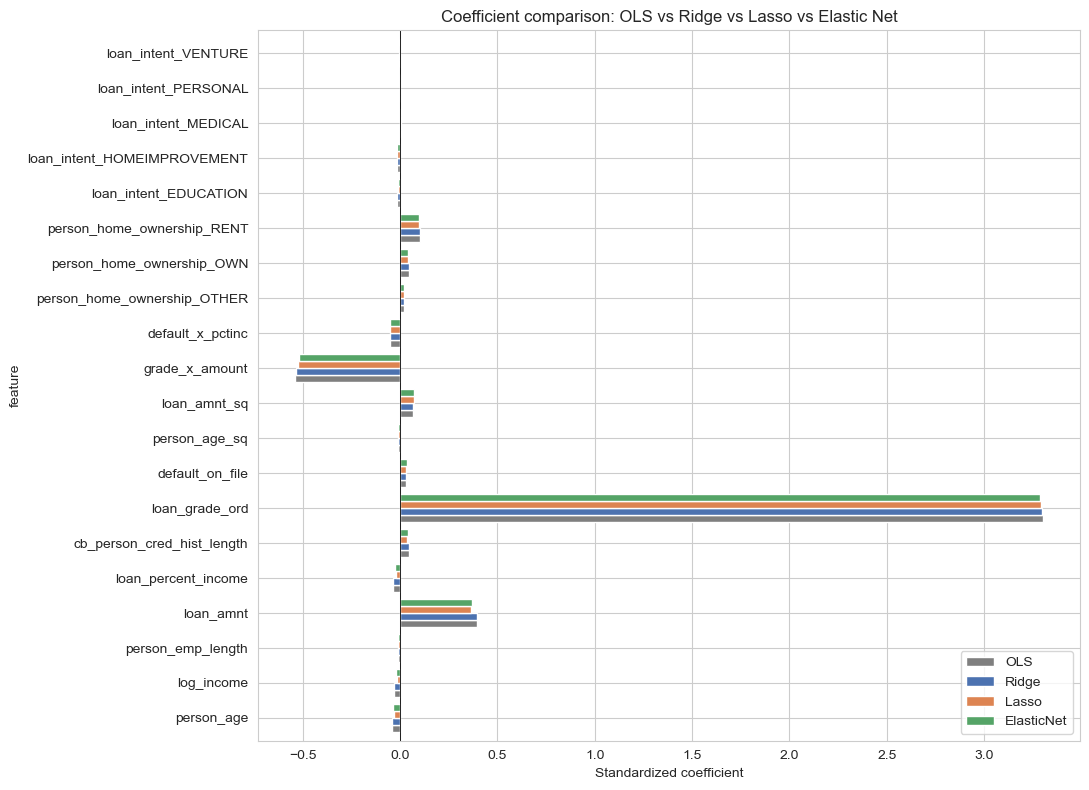

In [13]:
# Visual side-by-side
fig, ax = plt.subplots(figsize=(11, 8))
coef_table.plot(kind='barh', ax=ax, width=0.8,
                color=['#7f7f7f', '#4c72b0', '#dd8452', '#55a467'])
ax.axvline(0, color='black', lw=0.6)
ax.set_xlabel('Standardized coefficient')
ax.set_title('Coefficient comparison: OLS vs Ridge vs Lasso vs Elastic Net')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**What to look at in the table and bar plot**

- The **OLS** column is the unregularized reference — some coefficients are large in absolute value because nothing is restraining them.
- **Ridge** is a softened version of OLS: same signs, same general ordering, smaller magnitudes. Nothing is zero.
- **Lasso** has hard zeros for several less-important features (look at the rows where the Lasso bar is exactly at 0). On the collinear trio, lasso typically keeps the strongest signal and zeroes out its partner.
- **Elastic Net** lands between the two: more features survive than under pure lasso, but it still produces a sparser fit than ridge.

## 9 · Predictive performance comparison

In [14]:
results_df = pd.DataFrame(results).round(4)
results_df

,model,R2_train,R2_test,RMSE_test
0,OLS (no regularization),0.8775,0.8716,1.1656
1,Ridge (alpha=1.78),0.8775,0.8716,1.1656
2,Lasso (alpha=0.001),0.8775,0.8717,1.1652
3,"ElasticNet (a=0.001, l1=0.5)",0.8775,0.8717,1.1652


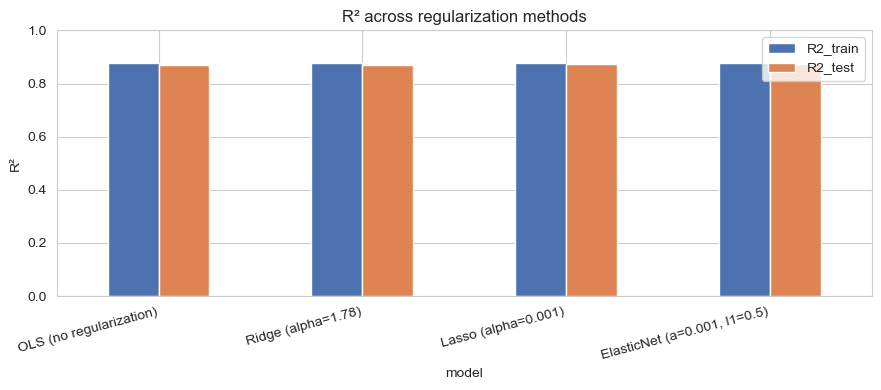

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
results_df.set_index('model')[['R2_train', 'R2_test']].plot(
    kind='bar', ax=ax, color=['#4c72b0', '#dd8452'])
ax.set_ylabel('R²'); ax.set_ylim(0, 1)
ax.set_title('R² across regularization methods')
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()

On this dataset the four methods score within a hair of each other on the test R². That outcome is itself the point: we are not in a "lasso saves us from overfitting" regime here — we have ~26k training rows and only ~25 features, so the OLS solution is already well-conditioned. The value of regularization shows up not in higher accuracy but in the **structure of the model**: lasso produces a sparser, more interpretable fit; ridge produces a more stable fit; elastic net offers a tunable middle ground.

## 10 · Conclusions and reflection

**Substantive findings**

1. **Lasso identifies the workhorse predictors.** The non-zeroed coefficients under lasso are the same ones that dominated the Week 1 OLS table — `loan_grade_ord`, `default_on_file`, `loan_percent_income`, plus the `grade_x_amount` interaction. That convergence between two independent methods adds confidence that those features really do drive interest rate.
2. **Ridge confirms collinearity is real but manageable.** Where Week 1 had to *drop* `loan_percent_income` to control VIF, ridge keeps it in and simply assigns proportional weight to it alongside the other collinear features. Two valid ways to handle the same problem; ridge requires less manual judgement.
3. **Elastic Net is the practical default when you don't know.** With the CV-chosen `l1_ratio` sitting between 0 and 1, the model self-selects how aggressively to prune — useful when we don't have a strong prior about whether the truth is "sparse" (favoring lasso) or "dense" (favoring ridge).
4. **Regularization didn't lift accuracy meaningfully here**, because the OLS problem is already well-posed at this n/p ratio. We would expect a bigger gap in a wide dataset (many features relative to rows), which is the scenario the reading's grocery-store thought experiment imagines.

**Reflection on the Week 2 reading questions**

*Why does lasso end up dropping some coefficients?* Because the L1 penalty has a sharp corner at zero. When the marginal improvement in fit from a non-zero β is less than λ, the optimum sits exactly on the corner.

*Why does ridge end up not dropping coefficients?* Because the L2 gradient at β = 0 is itself 0, so once a coefficient is small the penalty pressure to shrink it further also disappears. The minimum lives just shy of zero, never on it.

*When would you prefer lasso?* When you suspect most features are irrelevant and you want the model to perform feature selection automatically — wide datasets, exploratory work, or settings where interpretability matters.

*When would you prefer ridge?* When you believe many features each contribute a little, especially under multicollinearity, and you'd rather distribute coefficient mass across them than arbitrarily pick one.

*When would you prefer no regularization?* When you have far more rows than features, low collinearity, and you want unbiased coefficient estimates (e.g., for inference and hypothesis testing). Our Week 1 OLS table is a good example — we wanted the coefficient table for storytelling, and OLS gave us interpretable standard errors and p-values that regularized models do not.